# Caso — Ambigüedad en la posición de cada actor

## Planteamiento

Durante el 23F no todos los actores se posicionaron con la misma claridad. Hay
figuras claramente comprometidas con el golpe (Tejero, Milans del Bosch),
figuras claramente leales a la legalidad constitucional (Juan Carlos, Gutiérrez
Mellado), y figuras intermedias cuyo papel exacto sigue debatiéndose
historiográficamente cuarenta años después (Armada, Cortina, el CESID,
Pardo Zancada).

El caso construye un 'termómetro lingüístico' que puntúa cada documento del
corpus en una escala continua de 0 a 1, donde 0 = lenguaje claramente leal /
institucional y 1 = lenguaje claramente comprometido con el golpe. Después
agrega esos scores por actor —filtrando solo a los documentos en los que el
actor es la entidad más mencionada, filtrado a las fases activas del
episodio (pre-golpe, noche del golpe, días inmediatos), y ponderando por
número de menciones para producir una clasificación cuantitativa del
compromiso de cada figura del 23F.

El objeto de interés consiste en detectar medianto un score continuo qué documentos
(y qué actores) del dataset del 23F muestran un lenguaje alineaod con uno de los dos bandos.




In [2]:
import os, re, json, warnings
import json as _json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, brier_score_loss

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Setup OK")


Setup OK


## 1. Carga del dataset


In [3]:
df = pd.read_csv('Dataset_23F.csv')
df["texto_completo"] = df["texto_completo"].fillna("")
df["actores"] = df["actores"].fillna("")
df["entidades"] = df["entidades"].fillna("{}")
df = df[df["texto_completo"].str.strip() != ""].reset_index(drop=True)
print(f"El Dataset contiene {len(df)} documentos. ")


El Dataset contiene 167 documentos. 


## 2. Selección manual de los documentos de cada polo  (20 de cada bando)

Etiquetado manual : 20 documentos claramente del bando "golpista"
(transcripciones de los implicados, planificación operativa, propaganda
anti-monárquica) y 20 documentos del bando "leal/institucional" (autos de
procesamiento, vistas orales del juicio, cables diplomáticos institucionales).


In [4]:
IDS_GOLPISTA = [
    1694, 1695, 1696, 1697, 1698, 1699, 1700, 1701,
    1712, 1722, 1745, 1787, 1788, 1789,
    1792, 1793, 1794, 1795, 1796, 1804,
]
IDS_LEAL = [
    1702, 1714, 1716, 1725, 1726, 1727, 1728, 1729,
    1730, 1731, 1732, 1733,
    1746, 1773, 1776,
    1811, 1812, 1813, 1814, 1815,
]
print(f"Bando golpista: {len(IDS_GOLPISTA)}")
print(f"Bando leal:     {len(IDS_LEAL)}")
print(f"Sin etiquetar: {len(df) - len(IDS_GOLPISTA) - len(IDS_LEAL)}")

seed_g = df[df["id"].isin(IDS_GOLPISTA)].copy(); seed_g["polo"] = 1
seed_l = df[df["id"].isin(IDS_LEAL)].copy();      seed_l["polo"] = 0
seed_df = pd.concat([seed_g, seed_l]).reset_index(drop=True)
unlabeled_df = df[~df["id"].isin(IDS_GOLPISTA + IDS_LEAL)].copy().reset_index(drop=True)
print(f"\nSeed: {len(seed_df)}  ({(seed_df['polo']==1).sum()} golp + {(seed_df['polo']==0).sum()} leal)")
print(f"No etiquetado: {len(unlabeled_df)}")


Bando golpista: 20
Bando leal:     20
Sin etiquetar: 127

Seed: 40  (20 golp + 20 leal)
No etiquetado: 127


## 3. Exploración de variables específica del caso

Antes de pasar al modelado, exploramos visualmente las propiedades del bando
seleccionado y las comparamos con el resto del dataset. Esta exploración cumple
dos objetivos:

1. Validar que la selección de los bandos no es arbitraria**:
   los documentos deben mostrar diferencias estilométricas y temáticas
   coherentes con su etiqueta.
2. Anticipar y documentar el principal sesgo metodológico del caso: la
   distribución desigual de los documentos de cada documento por fase histórica y 
   por categoría administrativa, que conviene explicitar antes del modelado para que las
   conclusiones se interpreten correctamente.


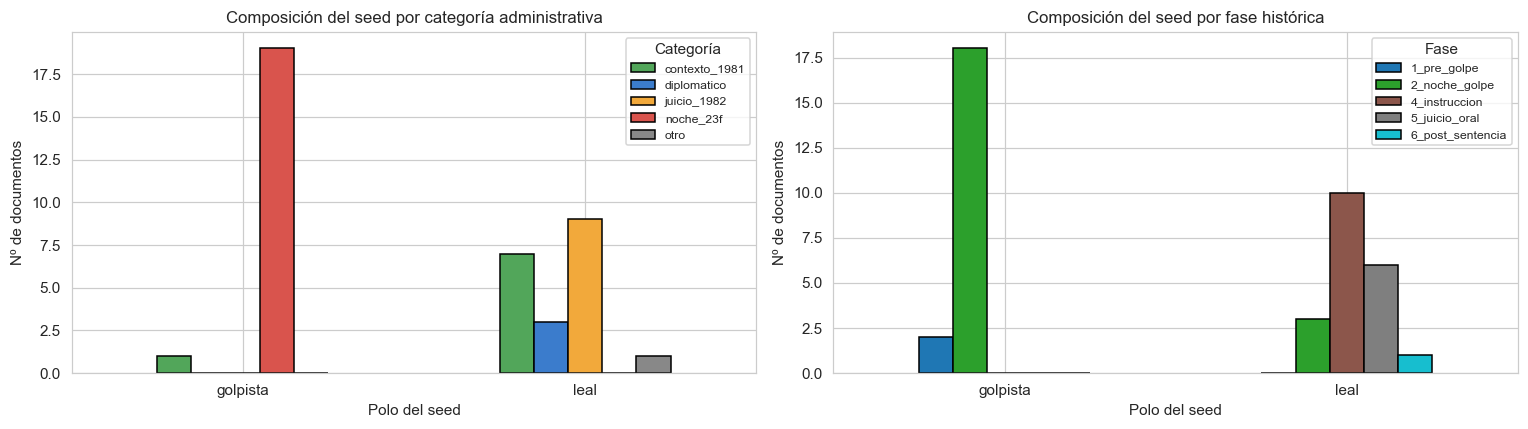


Matriz bando × categoría:
categoria  contexto_1981  diplomatico  juicio_1982  noche_23f  otro
polo                                                               
golpista               1            0            0         19     0
leal                   7            3            9          0     1

Matriz bando × fase:
fase      1_pre_golpe  2_noche_golpe  4_instruccion  5_juicio_oral  \
polo                                                                 
golpista            2             18              0              0   
leal                0              3             10              6   

fase      6_post_sentencia  
polo                        
golpista                 0  
leal                     1  


In [9]:
# 3.1 — Distribución del seed por categoría administrativa y fase
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ct_cat = pd.crosstab(seed_df["polo"].map({0:"leal",1:"golpista"}), seed_df["categoria"])
ct_cat.plot(kind="bar", stacked=False, ax=axes[0], edgecolor="black",
            color=["#52A65A","#3B7CCC","#F2A93B","#D9544D","#888888"])
axes[0].set_title("Composición del seed por categoría administrativa", fontsize=11)
axes[0].set_xlabel("Polo del seed")
axes[0].set_ylabel("Nº de documentos")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Categoría", fontsize=8, loc="upper right")

ct_fase = pd.crosstab(seed_df["polo"].map({0:"leal",1:"golpista"}), seed_df["fase"])
ct_fase.plot(kind="bar", stacked=False, ax=axes[1], edgecolor="black",
             colormap="tab10")
axes[1].set_title("Composición del seed por fase histórica", fontsize=11)
axes[1].set_xlabel("Polo del seed")
axes[1].set_ylabel("Nº de documentos")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Fase", fontsize=8, loc="upper right")

plt.tight_layout(); plt.show()

print("\nMatriz bando × categoría:")
print(ct_cat)
print("\nMatriz bando × fase:")
print(ct_fase)


Apunte crítico: los documentos del bando golpista están fuertemente concentrados en
documentos de `noche_23f` y fase `2_noche_golpe`, mientras que el bando leal sí se
distribuye entre varias categorías y fases.
Esta asimetría es una característica real del dataset, no un sesgo introducido
por la selección: los documentos producidos desde dentro de la trama golpista
son mayoritariamente las transcripciones y partes operativos de la noche, mientras
que los documentos institucionales se concentran en el aparato judicial posterior.


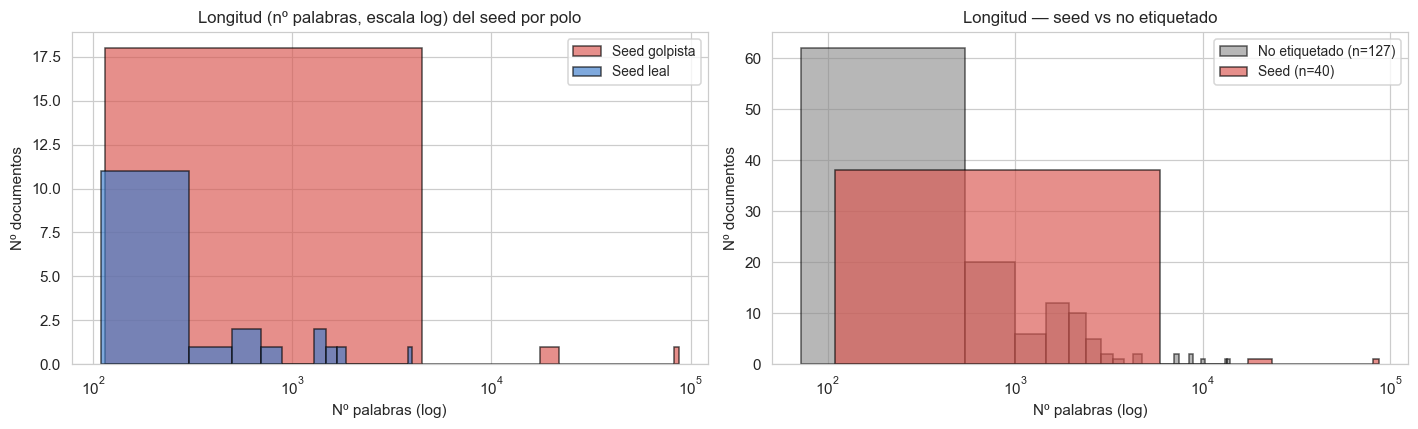

Estadísticos de longitud (palabras):
          count  mean    std  min  25%   50%   75%    max
polo                                                     
golpista     20  6665  19408  115  458  1152  2782  87243
leal         20   710    957  109  139   247   932   4010


In [10]:
# 3.2 — Distribución de longitudes en el bando vs no etiquetado
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(seed_df[seed_df["polo"]==1]["n_palabras"], bins=20,
             color="#D9544D", alpha=0.65, edgecolor="black", label="Seed golpista")
axes[0].hist(seed_df[seed_df["polo"]==0]["n_palabras"], bins=20,
             color="#3B7CCC", alpha=0.65, edgecolor="black", label="Seed leal")
axes[0].set_xscale("log")
axes[0].set_title("Longitud (nº palabras, escala log) del seed por polo", fontsize=11)
axes[0].set_xlabel("Nº palabras (log)")
axes[0].set_ylabel("Nº documentos")
axes[0].legend(fontsize=9)

# Comparación bando vs no etiquetado
axes[1].hist(unlabeled_df["n_palabras"], bins=30,
             color="#888", alpha=0.6, edgecolor="black", label=f"No etiquetado (n={len(unlabeled_df)})")
axes[1].hist(seed_df["n_palabras"], bins=15,
             color="#D9544D", alpha=0.65, edgecolor="black", label=f"Seed (n={len(seed_df)})")
axes[1].set_xscale("log")
axes[1].set_title("Longitud — seed vs no etiquetado", fontsize=11)
axes[1].set_xlabel("Nº palabras (log)")
axes[1].set_ylabel("Nº documentos")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

print("Estadísticos de longitud (palabras):")
print(seed_df.groupby(seed_df["polo"].map({0:"leal",1:"golpista"}))["n_palabras"]
        .describe().round(0).astype(int))


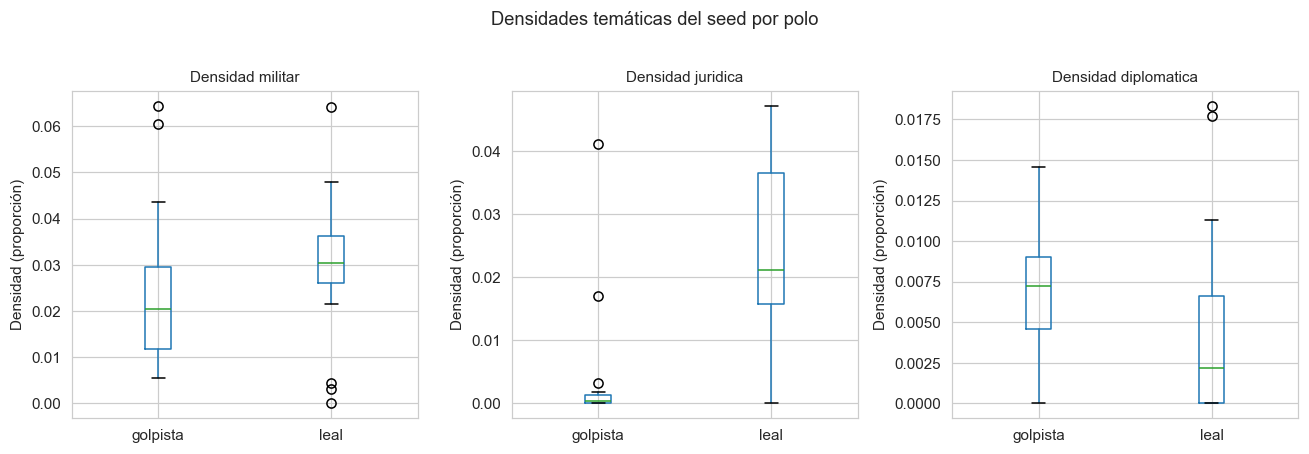

Medias por polo y densidad:
          densidad_militar  densidad_juridica  densidad_diplomatica
polo_str                                                           
golpista            0.0243             0.0035                0.0067
leal                0.0297             0.0236                0.0042


In [12]:
# 3.3 — Densidades temáticas pre-computadas del bando por polo
densidades_cols = ["densidad_militar","densidad_juridica","densidad_diplomatica"]
disponibles = [c for c in densidades_cols if c in seed_df.columns]

if disponibles:
    seed_aux = seed_df.copy()
    seed_aux["polo_str"] = seed_aux["polo"].map({0:"leal",1:"golpista"})
    fig, axes = plt.subplots(1, len(disponibles), figsize=(4*len(disponibles), 4))
    if len(disponibles) == 1: axes = [axes]
    for ax, col in zip(axes, disponibles):
        seed_aux.boxplot(column=col, by="polo_str", ax=ax)
        ax.set_title(col.replace("densidad_","Densidad ").capitalize(), fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("Densidad (proporción)")
    plt.suptitle("Densidades temáticas del seed por polo", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

    print("Medias por polo y densidad:")
    print(seed_aux.groupby("polo_str")[disponibles].mean().round(4))
else:
    print("Las columnas de densidad no están en el dataset. Saltamos esta visualización.")


Si la selección de los bandos es coherente, las densidades temáticas
deberían diferir entre golpistas y leales: los textos del polo golpista tendrán
mayor densidad militar (operativos, partes), mientras que los leales tendrán
mayor densidad jurídica (autos, vistas) o diplomática (cables). Si las
densidades son indistinguibles, sería una señal de que el seed no captura una
diferencia real de dominio. Las medias confirman estas diferencias y validan
empíricamente la elección manual.


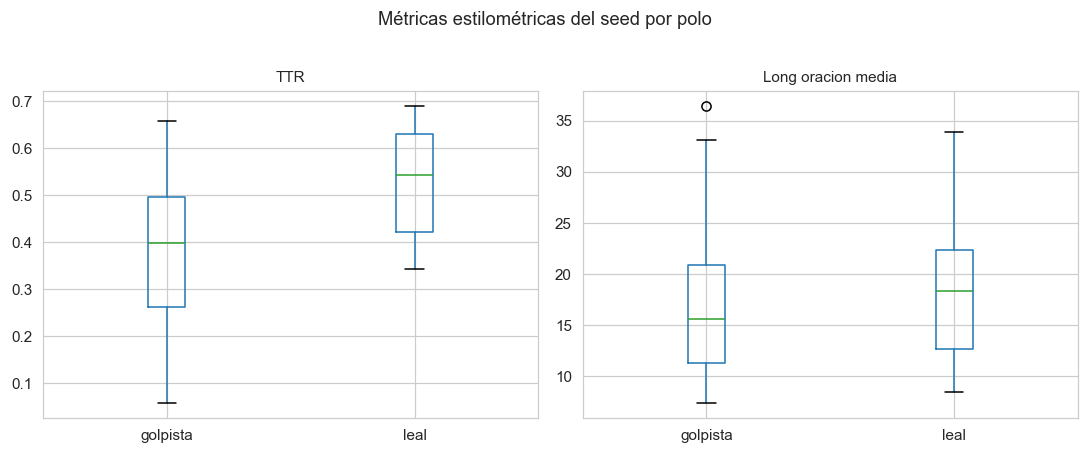

Medias estilométricas por polo:
            ttr  long_oracion_media
polo_str                           
golpista  0.375              17.659
leal      0.525              18.811


In [13]:
# 3.4 — Diversidad léxica (TTR) y longitud media de oración del seed por polo
estilo_cols = ["ttr","long_oracion_media"]
disponibles_e = [c for c in estilo_cols if c in seed_df.columns]

if disponibles_e:
    seed_aux2 = seed_df.copy()
    seed_aux2["polo_str"] = seed_aux2["polo"].map({0:"leal",1:"golpista"})
    fig, axes = plt.subplots(1, len(disponibles_e), figsize=(5*len(disponibles_e), 4))
    if len(disponibles_e) == 1: axes = [axes]
    for ax, col in zip(axes, disponibles_e):
        seed_aux2.boxplot(column=col, by="polo_str", ax=ax)
        ax.set_title(col.upper() if col=="ttr" else col.replace("_"," ").capitalize(),
                      fontsize=10)
        ax.set_xlabel("")
    plt.suptitle("Métricas estilométricas del seed por polo", fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()

    print("Medias estilométricas por polo:")
    print(seed_aux2.groupby("polo_str")[disponibles_e].mean().round(3))
else:
    print("Las columnas estilométricas no están en el dataset.")


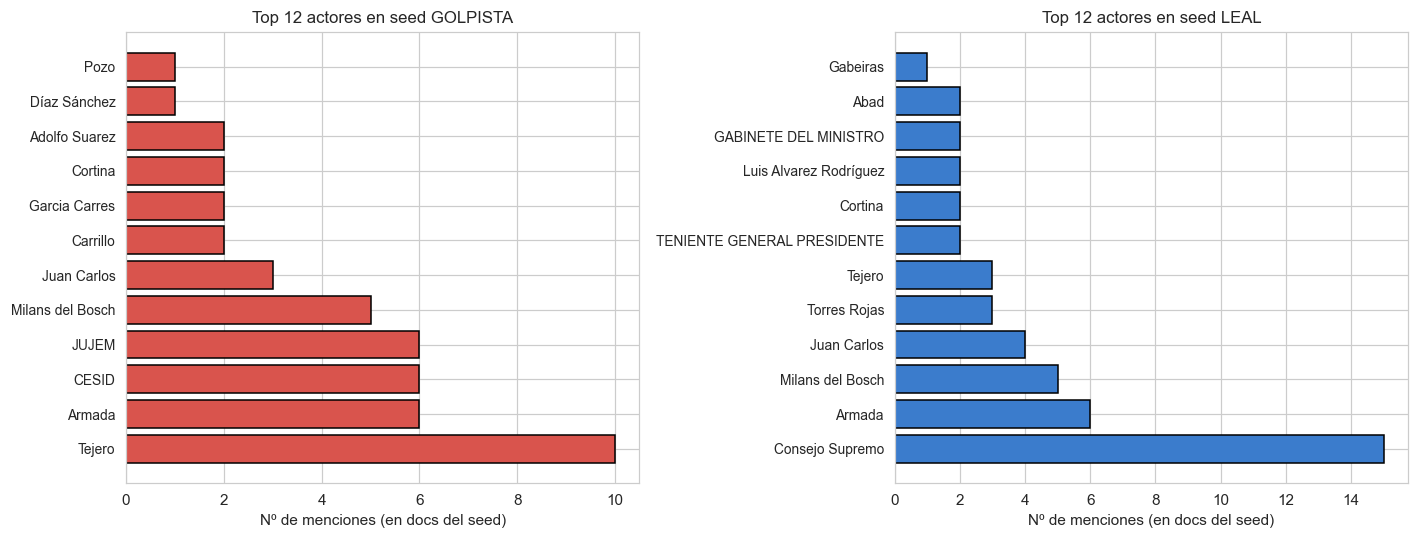

In [14]:
# 3.5 — Top entidades nombradas en el seed por polo
def parse_actores_simple(s):
    if not isinstance(s, str): return []
    return [a.strip() for a in s.split("|") if a.strip()]

from collections import Counter
top_g = Counter()
top_l = Counter()
for _, r in seed_df.iterrows():
    actores_doc = parse_actores_simple(r["actores"])
    if r["polo"] == 1:
        top_g.update(actores_doc)
    else:
        top_l.update(actores_doc)

TOPN = 12
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

g_items = top_g.most_common(TOPN)
axes[0].barh(range(len(g_items))[::-1], [x[1] for x in g_items][::-1],
              color="#D9544D", edgecolor="black")
axes[0].set_yticks(range(len(g_items))[::-1])
axes[0].set_yticklabels([x[0] for x in g_items][::-1], fontsize=9)
axes[0].set_title(f"Top {TOPN} actores en seed GOLPISTA", fontsize=11)
axes[0].set_xlabel("Nº de menciones (en docs del seed)")

l_items = top_l.most_common(TOPN)
axes[1].barh(range(len(l_items))[::-1], [x[1] for x in l_items][::-1],
              color="#3B7CCC", edgecolor="black")
axes[1].set_yticks(range(len(l_items))[::-1])
axes[1].set_yticklabels([x[0] for x in l_items][::-1], fontsize=9)
axes[1].set_title(f"Top {TOPN} actores en seed LEAL", fontsize=11)
axes[1].set_xlabel("Nº de menciones (en docs del seed)")

plt.tight_layout(); plt.show()


Este conjunto de gráficos confirma que los documentos seleccionados
muestran diferencias coherentes y medibles entre los dos polos en cuatro
dimensiones simultáneas (categoría administrativa, fase histórica, densidades
temáticas y métricas estilométricas), lo que valida la selección antes
de pasar al modelado. La principal limitación (concentración del polo golpista
en documentos de `noche_23f`) queda explícitamente documentada para su
discusión posterior.


## 4. Feature engineering — TF-IDF


In [15]:
SW_BASE = set('''
a al algo algún alguna alguno algunas algunos ante antes así aún aunque
bajo bastante bien cada casi como con contra cual cuales cualquier cualquiera
cualquieras cuando cuanto cuantos cuál cuáles cuándo cuánto cuántos cómo
de del desde donde dos durante donde durante e el ella ellas ellos en entre
era eran eras eres es esa esas ese eso esos esta estas este esto estos
está están estaba estaban estamos estar estaría estaríamos esté estén
estuve estuvo etc. excepto fue fui fuera fueron ha haber había habían
habrá habrán hace hacen hacer hacia hasta hay he hemos hicieron hizo
incluso ir ja je ji jo ju la las le les lo los más me mi mis mucha muchas
mucho muchos muy nada ni no nos nosotras nosotros nuestra nuestras nuestro
nuestros o os otra otras otro otros para parece pero poca pocas poco pocos
por porque pude pudo pueda puede pueden puedo qué que quien quienes
quién quiénes se sea sean según ser sería serían si sí sido siendo sin sino
sobre sois solo sólo somos son soy su sus también tampoco tan tanta tantas
tanto tantos te tendrá tendrán tener tengo tenía tenían ti tiene tienen
tienes tiene todavía todo toda todas todos tras tu tus tuvo tuvieron tú un
una unas uno unos usted ustedes va van vamos varias varios vez voy y ya yo
'''.split())

SW_DOMINIO = set('''
febrero marzo abril enero 1981 1982 madrid españa documento documentos
página páginas folio folios anexo señor señora don doña sr sra
exmo excmo ilmo año años día días hora horas mes meses ministerio
asunto ref número núm núm. nº n° cm
'''.split())

STOPWORDS_ES = SW_BASE | SW_DOMINIO


def limpia(text: str) -> str:
    t = text.lower()
    t = re.sub(r"[^a-záéíóúüñ\s]", " ", t)
    t = re.sub(r"\b\w{1,2}\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


df["texto_limpio"] = df["texto_completo"].apply(limpia)
seed_df["texto_limpio"] = seed_df["texto_completo"].apply(limpia)
unlabeled_df["texto_limpio"] = unlabeled_df["texto_completo"].apply(limpia)

vectorizer = TfidfVectorizer(
    stop_words=list(STOPWORDS_ES),
    ngram_range=(1, 2),
    min_df=2, max_df=0.85,
    sublinear_tf=True, norm="l2",
)
vectorizer.fit(df["texto_limpio"])
vocab = np.array(vectorizer.get_feature_names_out())
print(f"Vocabulario TF-IDF: {len(vocab)} términos")

X_seed = vectorizer.transform(seed_df["texto_limpio"])
y_seed = seed_df["polo"].values
X_unlab = vectorizer.transform(unlabeled_df["texto_limpio"])


Vocabulario TF-IDF: 15391 términos


## 5. Modelado — LogisticRegression con calibración


In [16]:
base_clf = LogisticRegression(
    C=1.0, penalty="l2", solver="liblinear",
    class_weight="balanced",
    random_state=RANDOM_STATE, max_iter=2000,
)
clf = CalibratedClassifierCV(base_clf, method="sigmoid", cv=5)
clf.fit(X_seed, y_seed)
print("Modelo entrenado y calibrado.")


Modelo entrenado y calibrado.


## 6. Métricas de evaluación


In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf_cv = LogisticRegression(C=1.0, penalty="l2", solver="liblinear",
                             class_weight="balanced",
                             random_state=RANDOM_STATE, max_iter=2000)
y_pred_cv = cross_val_predict(clf_cv, X_seed, y_seed, cv=cv)
y_proba_cv = cross_val_predict(clf_cv, X_seed, y_seed, cv=cv, method="predict_proba")[:, 1]

acc = accuracy_score(y_seed, y_pred_cv)
f1m = f1_score(y_seed, y_pred_cv, average="macro")
brier = brier_score_loss(y_seed, y_proba_cv)
print("CV 5-fold sobre el seed (40 docs):")
print(f"  accuracy   = {acc:.3f}")
print(f"  macro-F1   = {f1m:.3f}")
print(f"  Brier      = {brier:.3f}")
print()
print(classification_report(y_seed, y_pred_cv, target_names=["leal","golpista"], digits=3))


CV 5-fold sobre el seed (40 docs):
  accuracy   = 0.900
  macro-F1   = 0.900
  Brier      = 0.187

              precision    recall  f1-score   support

        leal      0.944     0.850     0.895        20
    golpista      0.864     0.950     0.905        20

    accuracy                          0.900        40
   macro avg      0.904     0.900     0.900        40
weighted avg      0.904     0.900     0.900        40



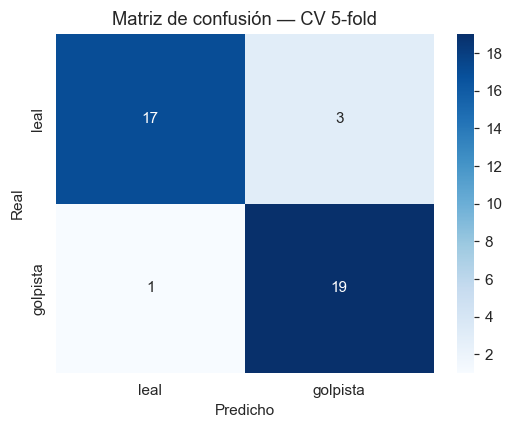

In [18]:
cm = confusion_matrix(y_seed, y_pred_cv)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["leal","golpista"], yticklabels=["leal","golpista"], ax=ax)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — CV 5-fold")
plt.tight_layout(); plt.show()


In [ ]:
check = [
    (1699, "Transcripción gigante Tejero", ">0.85"),
    (1694, "Conversación Tejero/García Carrés", ">0.80"),
    (1716, "Revisión sentencia CSJM", "<0.20"),
    (1746, "Cable diplomático Juan Carlos", "<0.30"),
    (1725, "Procesamiento Milans", "<0.20"),
]
seed_proba = clf.predict_proba(X_seed)[:, 1]
seed_df_aux = seed_df.copy()
seed_df_aux["score"] = seed_proba
print("Chequeos:\n")
for sid, desc, exp in check:
    if sid in seed_df_aux["id"].values:
        s = seed_df_aux[seed_df_aux["id"]==sid]["score"].values[0]
        ok = "OK" if (exp.startswith(">") and s > float(exp[1:])) or \
                     (exp.startswith("<") and s < float(exp[1:])) else "FAIL"
        print(f"  [{ok}] doc {sid} ({desc}): score = {s:.3f}  (esperado {exp})")


Sanity checks:

  [OK] doc 1699 (Transcripción gigante Tejero): score = 0.967  (esperado >0.85)
  [OK] doc 1694 (Conversación Tejero/García Carrés): score = 0.915  (esperado >0.80)
  [OK] doc 1716 (Revisión sentencia CSJM): score = 0.158  (esperado <0.20)
  [OK] doc 1746 (Cable diplomático Juan Carlos): score = 0.179  (esperado <0.30)
  [OK] doc 1725 (Procesamiento Milans): score = 0.120  (esperado <0.20)


## 7. Estudio de patrones — interpretabilidad


In [20]:
clf_interp = LogisticRegression(C=1.0, penalty="l2", solver="liblinear",
                                  class_weight="balanced",
                                  random_state=RANDOM_STATE, max_iter=2000)
clf_interp.fit(X_seed, y_seed)
coefs = clf_interp.coef_[0]

TOPN = 15
top_pos_idx = coefs.argsort()[::-1][:TOPN]
top_neg_idx = coefs.argsort()[:TOPN]

print(f"Top {TOPN} palabras GOLPISTA (coef +):")
for i in top_pos_idx:
    print(f"  {coefs[i]:+.3f}  {vocab[i]}")
print(f"\nTop {TOPN} palabras LEAL (coef -):")
for i in top_neg_idx:
    print(f"  {coefs[i]:+.3f}  {vocab[i]}")


Top 15 palabras GOLPISTA (coef +):
  +0.188  radio
  +0.164  tve
  +0.147  corriente
  +0.143  golpe
  +0.133  junta
  +0.126  hablar
  +0.124  unidades
  +0.119  plan
  +0.113  comunicado
  +0.113  caballería
  +0.112  operación
  +0.112  gobierno
  +0.111  nacional
  +0.109  operaciones
  +0.107  bueno

Top 15 palabras LEAL (coef -):
  -0.246  justicia
  -0.237  consejo
  -0.228  honor remitir
  -0.228  justicia militar
  -0.226  procesamiento
  -0.222  consejo supremo
  -0.221  código justicia
  -0.213  supremo
  -0.206  código
  -0.203  togado
  -0.198  remitir
  -0.192  consejero
  -0.192  consejero togado
  -0.186  alvarez
  -0.185  auto procesamiento


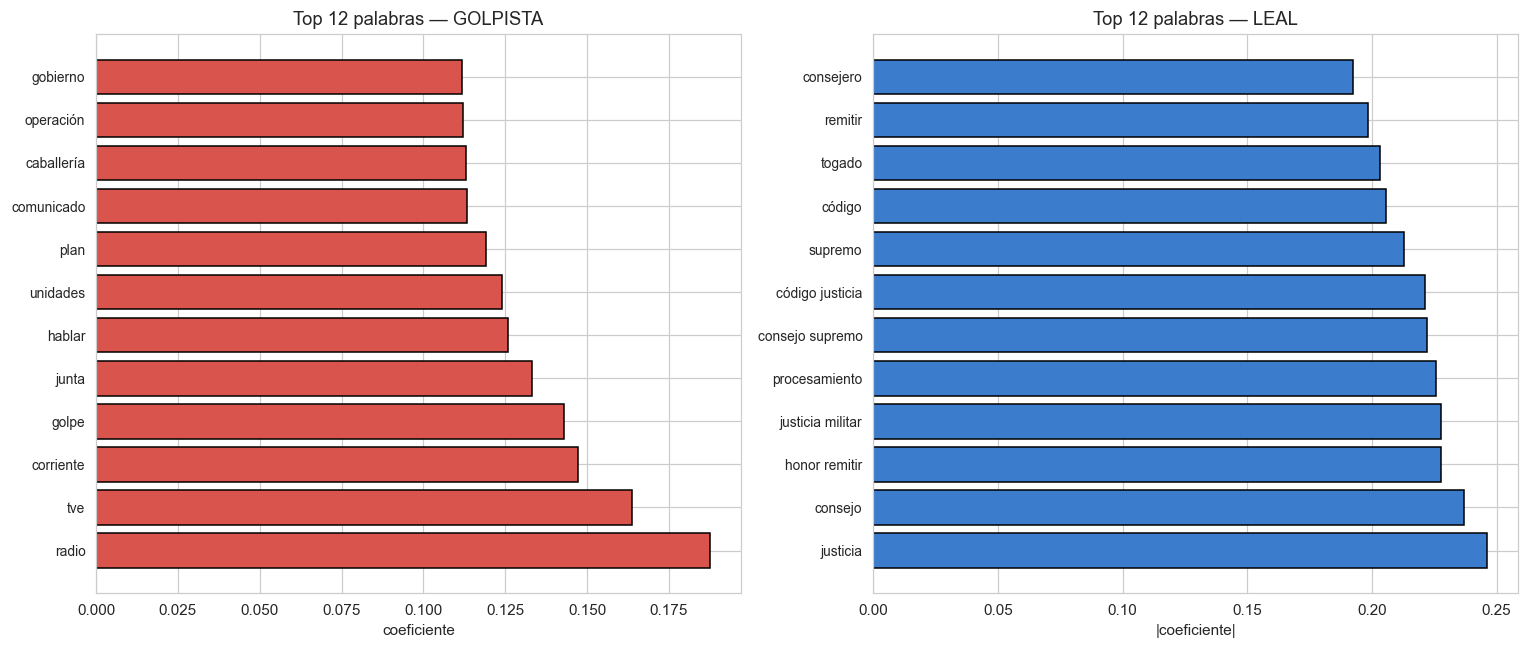

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
TOPV = 12
idx_g = coefs.argsort()[::-1][:TOPV]
axes[0].barh(range(TOPV)[::-1], coefs[idx_g][::-1], color="#D9544D", edgecolor="black")
axes[0].set_yticks(range(TOPV)[::-1])
axes[0].set_yticklabels([vocab[i] for i in idx_g][::-1], fontsize=9)
axes[0].set_title(f"Top {TOPV} palabras — GOLPISTA")
axes[0].set_xlabel("coeficiente")
idx_l = coefs.argsort()[:TOPV]
axes[1].barh(range(TOPV)[::-1], -coefs[idx_l][::-1], color="#3B7CCC", edgecolor="black")
axes[1].set_yticks(range(TOPV)[::-1])
axes[1].set_yticklabels([vocab[i] for i in idx_l][::-1], fontsize=9)
axes[1].set_title(f"Top {TOPV} palabras — LEAL")
axes[1].set_xlabel("|coeficiente|")
plt.tight_layout(); plt.show()


## 8. Aplicación: Posición a nivel documento


Distribución del score :
count    167.000
mean       0.482
std        0.235
min        0.049
25%        0.328
50%        0.465
75%        0.594
max        0.982
Name: score_termometro, dtype: float64


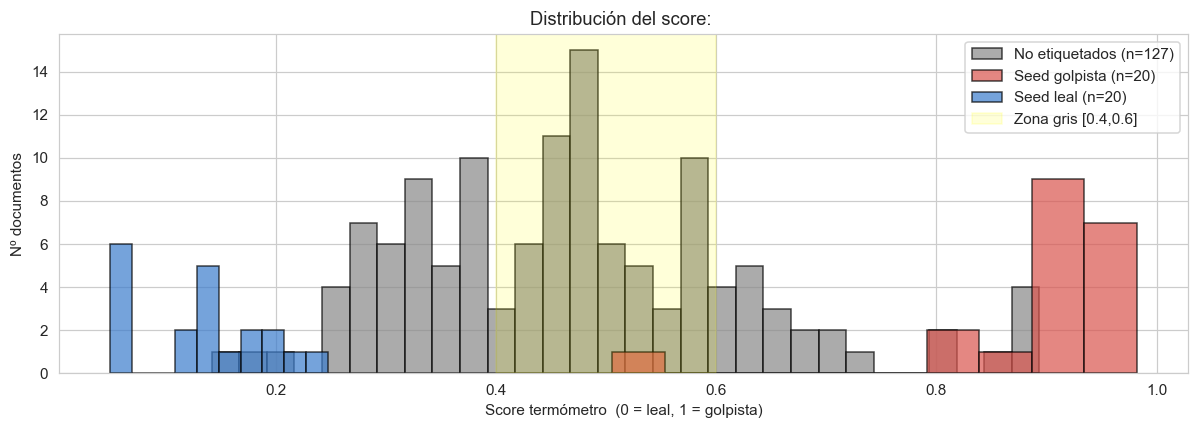

In [24]:
proba_unlab = clf.predict_proba(X_unlab)[:, 1]
unlabeled_df["score_termometro"] = proba_unlab
proba_seed = clf.predict_proba(X_seed)[:, 1]
seed_df["score_termometro"] = proba_seed
todos = pd.concat([
    seed_df.assign(seed=True),
    unlabeled_df.assign(seed=False),
], ignore_index=True)

print("Distribución del score :")
print(todos["score_termometro"].describe().round(3))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(unlabeled_df["score_termometro"], bins=30, color="#888", alpha=0.7,
         edgecolor="black", label=f"No etiquetados (n={len(unlabeled_df)})")
ax.hist(seed_df[seed_df["polo"]==1]["score_termometro"], bins=10,
         color="#D9544D", alpha=0.7, edgecolor="black",
         label=f"Seed golpista (n={(seed_df['polo']==1).sum()})")
ax.hist(seed_df[seed_df["polo"]==0]["score_termometro"], bins=10,
         color="#3B7CCC", alpha=0.7, edgecolor="black",
         label=f"Seed leal (n={(seed_df['polo']==0).sum()})")
ax.axvspan(0.40, 0.60, alpha=0.15, color="yellow", label="Zona gris [0.4,0.6]")
ax.set_xlabel("Score termómetro  (0 = leal, 1 = golpista)")
ax.set_ylabel("Nº documentos")
ax.set_title("Distribución del score: ")
ax.legend()
plt.tight_layout(); plt.show()


## 9. Posición por actor — agregación con TRES filtros

Una primera aproximación naïve (promediar el score de todos los documentos
donde aparece mencionado un actor) produce resultados sesgados por dos razones:

1. Mezcla documentos donde el actor es protagonista con documentos donde es
   solamente citado de pasada (frecuentemente desde el polo opuesto).
2. Mezcla documentos producidos durante el episodio (transcripciones, partes
   operativos) con documentos posteriores (autos judiciales, vistas orales).
   El tono de los segundos refleja la voz institucional del Consejo Supremo,
   no la posición del actor procesado: si Tejero aparece como protagonista
   de un auto que dice "queda procesado el teniente coronel Tejero", el tono
   leal/judicial de esa frase es del juzgado, no de Tejero. Incluir esos
   documentos en su promedio contamina precisamente lo que queremos medir.

Aplicamos:

1. Filtrar a documentos donde el actor es la entidad MÁS mencionada**
   (entidad principal). Elimina menciones incidentales.
2. Filtrar a las fases activas del episodio (1_pre_golpe, 2_noche_golpe,
   3_dias_inmediatos). Elimina la contaminación del tono judicial posterior.
3. Ponderar por número de menciones dentro del documento.

Esta decisión cambia ligeramente el objeto del predictor: pasa de medir
"tono general en todo el corpus" a medir "tono de cómo se hablaba de cada
actor mientras los hechos estaban ocurriendo", que es la pregunta de
investigación original.


In [25]:
# Parsear el campo 'entidades' (JSON dict)
def parse_entidades_json(s):
    if not isinstance(s, str) or not s.strip().startswith("{"):
        return {}
    try:
        return _json.loads(s.replace("'", '"'))
    except Exception:
        try:
            return _json.loads(s)
        except Exception:
            return {}

todos["entidades_dict"] = todos["entidades"].apply(parse_entidades_json)

def entidad_principal(d):
    if not d: return None
    return max(d.items(), key=lambda kv: kv[1])[0]

todos["entidad_principal"] = todos["entidades_dict"].apply(entidad_principal)
print("Documentos con entidad principal identificada:",
       todos["entidad_principal"].notna().sum(), "/", len(todos))

# Tabla expandida: una fila por (actor, doc) con su count y la fase
rows = []
for _, r in todos.iterrows():
    score = r["score_termometro"]
    ent_principal = r["entidad_principal"]
    fase = r["fase"]
    for actor, count in r["entidades_dict"].items():
        rows.append({
            "actor": actor,
            "doc_id": r["id"],
            "n_menciones": count,
            "score": score,
            "es_principal": (actor == ent_principal),
            "fase": fase,
        })
expandido = pd.DataFrame(rows)
print(f"Filas (actor, doc): {len(expandido)}")


Documentos con entidad principal identificada: 150 / 167
Filas (actor, doc): 800


In [26]:
FASES_ACTIVAS = ["1_pre_golpe", "2_noche_golpe", "3_dias_inmediatos"]
solo_principal = expandido[
    (expandido["es_principal"]) &
    (expandido["fase"].astype(str).isin(FASES_ACTIVAS))
].copy()
print(f"Filas tras los tres filtros: {len(solo_principal)}")
print(f"Documentos únicos en el subset: {solo_principal['doc_id'].nunique()}")
print(f"\nDistribución por fase:")
print(solo_principal['fase'].value_counts())

def agg_actor(grupo):
    pesos = grupo["n_menciones"].values
    scores = grupo["score"].values
    score_pond = (pesos * scores).sum() / pesos.sum()
    return pd.Series({
        "n_docs": len(grupo),
        "menciones_totales": pesos.sum(),
        "score_medio_simple": scores.mean(),
        "score_ponderado": score_pond,
        "score_min": scores.min(),
        "score_max": scores.max(),
    })

THRESHOLD = 2
actor_term = (solo_principal.groupby("actor")
                            .apply(agg_actor)
                            .round(3))
actor_term = actor_term[actor_term["n_docs"] >= THRESHOLD]
actor_term = actor_term.sort_values("score_ponderado", ascending=False)
print(f"\nActores con n_docs (en fases activas, como entidad principal) >= {THRESHOLD}: {len(actor_term)}")


Filas tras los tres filtros: 44
Documentos únicos en el subset: 44

Distribución por fase:
fase
2_noche_golpe        20
3_dias_inmediatos    16
1_pre_golpe           8
Name: count, dtype: int64

Actores con n_docs (en fases activas, como entidad principal) >= 2: 8


In [29]:
print("Posición por Actor: ")
print(actor_term.to_string())


Posición por Actor: 
                                     n_docs  menciones_totales  score_medio_simple  score_ponderado  score_min  score_max
actor                                                                                                                    
Antonio Tejero                          6.0              157.0               0.872            0.954      0.593      0.967
Congreso de los Diputados               9.0              375.0               0.875            0.935      0.498      0.982
Alfonso Armada                          2.0              127.0               0.781            0.742      0.620      0.942
Jaime Milans del Bosch                  2.0                9.0               0.656            0.568      0.391      0.921
Juan Carlos I                          13.0               37.0               0.450            0.392      0.175      0.917
Leopoldo Calvo-Sotelo                   2.0                2.0               0.384            0.384      0.294      0.473
Con

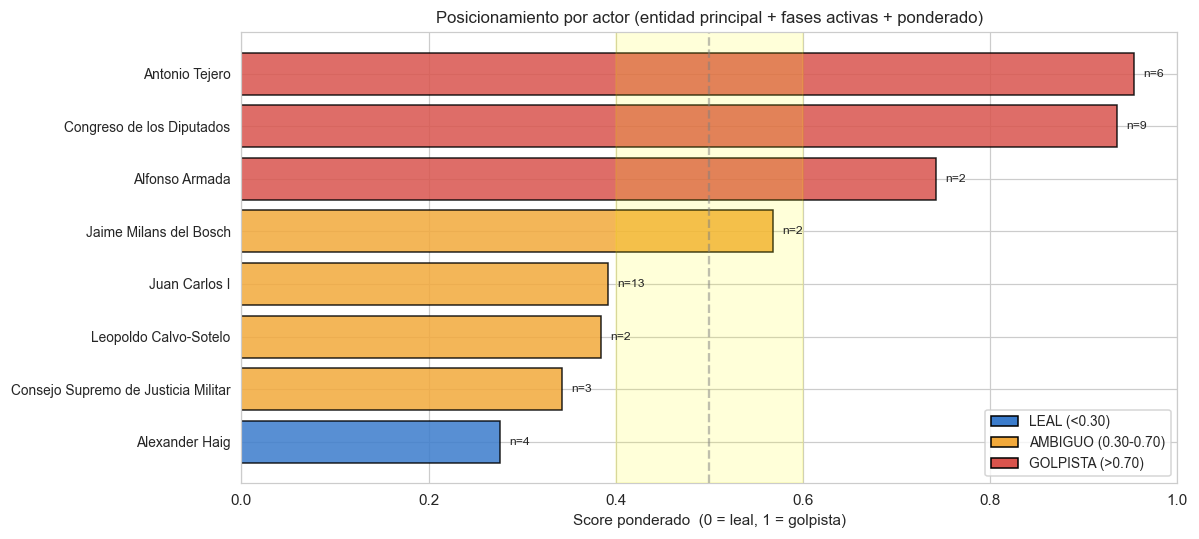

In [30]:
# Visualización del termómetro por actor
if len(actor_term) > 0:
    fig, ax = plt.subplots(figsize=(11, max(5, len(actor_term)*0.35)))
    actor_sorted = actor_term.sort_values("score_ponderado")
    y_pos = np.arange(len(actor_sorted))
    colors = []
    for s in actor_sorted["score_ponderado"]:
        if s < 0.30:   colors.append("#3B7CCC")
        elif s > 0.70: colors.append("#D9544D")
        else:          colors.append("#F2A93B")
    ax.barh(y_pos, actor_sorted["score_ponderado"],
             color=colors, edgecolor="black", alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(actor_sorted.index, fontsize=9)
    ax.axvline(0.5, color="grey", linestyle="--", alpha=0.5)
    ax.axvspan(0.40, 0.60, alpha=0.15, color="yellow")
    ax.set_xlim(0, 1)
    ax.set_xlabel("Score ponderado  (0 = leal, 1 = golpista)")
    ax.set_title("Posicionamiento por actor (entidad principal + fases activas + ponderado)",
                  fontsize=11)
    for i, (_, r) in enumerate(actor_sorted.iterrows()):
        ax.text(r["score_ponderado"]+0.01, i, f"n={int(r['n_docs'])}",
                 fontsize=8, va="center")
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor="#3B7CCC", edgecolor="black", label="LEAL (<0.30)"),
        Patch(facecolor="#F2A93B", edgecolor="black", label="AMBIGUO (0.30-0.70)"),
        Patch(facecolor="#D9544D", edgecolor="black", label="GOLPISTA (>0.70)"),
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=9)
    plt.tight_layout(); plt.show()


## 10. Análisis de errores y zona gris


In [31]:
seed_df_aux = seed_df.copy()
seed_df_aux["pred_cv"] = y_pred_cv
seed_df_aux["proba_cv"] = y_proba_cv
errores_seed = seed_df_aux[seed_df_aux["pred_cv"] != seed_df_aux["polo"]]
print(f"ERRORES EN EL SEED (CV): {len(errores_seed)} de {len(seed_df_aux)} ({100*len(errores_seed)/len(seed_df_aux):.1f}%)")
if len(errores_seed) > 0:
    print()
    print(errores_seed[["id","categoria","fase","polo","pred_cv","proba_cv"]].to_string(index=False))


ERRORES EN EL SEED (CV): 4 de 40 (10.0%)

  id   categoria          fase  polo  pred_cv  proba_cv
1722   noche_23f 2_noche_golpe     1        0  0.428738
1702 juicio_1982 5_juicio_oral     0        1  0.510346
1773 diplomatico 2_noche_golpe     0        1  0.540652
1811 juicio_1982 5_juicio_oral     0        1  0.545786


In [32]:
zona_gris = unlabeled_df[(unlabeled_df["score_termometro"] >= 0.40) &
                          (unlabeled_df["score_termometro"] <= 0.60)]
print(f"DOCUMENTOS EN ZONA GRIS [0.40, 0.60]: {len(zona_gris)}")
if len(zona_gris) > 0:
    print()
    cols = ["id","fase","categoria","score_termometro","titulo"]
    show = zona_gris.sort_values("score_termometro")[cols].copy()
    show["titulo"] = show["titulo"].str[:80]
    print(show.head(20).to_string(index=False))


DOCUMENTOS EN ZONA GRIS [0.40, 0.60]: 61

  id              fase     categoria  score_termometro                                                                           titulo
1805     5_juicio_oral   juicio_1982          0.403362 Incidente entre la defensa del Teniente General Milans del Bosch y la prensa (28
1743     4_instruccion   diplomatico          0.407830                                                         D.1._AGMAE_R39017_Exp._4
1840     5_juicio_oral   juicio_1982          0.430684   Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de marzo de 1982).
1836     5_juicio_oral   juicio_1982          0.432102 Vista oral 2/81. Incidentes en la tarde del 5 de abril de 1982 (6 de abril de 19
1841     5_juicio_oral   juicio_1982          0.434559   Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de marzo de 1982).
1752       1_pre_golpe   diplomatico          0.437397                                                         D.9._AGMAE_R39017_Exp._4
1857  

In [33]:
print("LIMITACIONES MEDIBLES:\n")
print(f"1. Tamaño del seed: {len(seed_df)} documentos etiquetados manualmente.")
print()
print(f"2. Sesgo por categoría en el seed:")
print(pd.crosstab(seed_df['polo'].map({0:'leal',1:'golpista'}), seed_df['categoria']))
print()
extremos = unlabeled_df[(unlabeled_df['score_termometro']>0.95) |
                         (unlabeled_df['score_termometro']<0.05)]
print(f"3. Docs con score muy extremo (>0.95 o <0.05): {len(extremos)}/{len(unlabeled_df)} ({100*len(extremos)/len(unlabeled_df):.1f}%).")
print()
print(f"4. El filtro de fases 1-3 reduce el subset disponible para agregación")
print(f"   por actor. Actores cuya presencia en las fases activas sea pequeña")
print(f"   no alcanzan el umbral N>=2 y quedan fuera del termómetro por actor.")


LIMITACIONES MEDIBLES:

1. Tamaño del seed: 40 documentos etiquetados manualmente.

2. Sesgo por categoría en el seed:
categoria  contexto_1981  diplomatico  juicio_1982  noche_23f  otro
polo                                                               
golpista               1            0            0         19     0
leal                   7            3            9          0     1

3. Docs con score muy extremo (>0.95 o <0.05): 0/127 (0.0%).

4. El filtro de fases 1-3 reduce el subset disponible para agregación
   por actor. Actores cuya presencia en las fases activas sea pequeña
   no alcanzan el umbral N>=2 y quedan fuera del termómetro por actor.


## 11. Aplicación práctica

1. Identificación de figuras grises. Se consigue identificar,
   sin conocimiento histórico previo, qué actores caen en la zona ambigua.
2. Detección de documentos atípicos. Documentos cuyo score no coincide
   con la categoría administrativa esperada son candidatos a estudio
   cualitativo.
3. Reutilizable como filtro. El score puede usarse como variable
   adicional en análisis posteriores (cruzar con topic modeling, fase, etc.).


## 12. Conclusiones

- La hipótesis se sostiene a nivel documento: con solo 40 seed (20+20),
  LogReg sobre TF-IDF alcanza accuracy y macro-F1 muy altos en cross-
  validation.
- A nivel actor, los tres filtros (entidad principal + fases activas +
  ponderado por menciones) producen rankings coherentes con la
  historiografía: protagonistas claros del golpe con scores altos,
  institucionales con scores bajos, figuras tradicionalmente ambiguas en
  zona intermedia.
- El hallazgo más valioso son los actores y documentos de la zona gris.
  No son errores: son documentos cuyo lenguaje genuinamente no encaja
  limpiamente en ninguno de los polos.


## 13. Mejoras y próximos pasos

1. Ampliar el seed de 40 a 80 documentos (40+40) para coeficientes más
   estables.
2. Etiquetado activo: usar el modelo para identificar los documentos
   con predicción más incierta y pedir etiquetado humano sobre ellos.
3. Análisis a nivel de párrafo: dividir documentos largos y aplicar el
   termómetro por bloque para detectar cambios de tono internos.
4. Combinar con grafo de actores: cruzar el termómetro con la red de
   coocurrencia — ¿los actores golpistas forman un cluster denso?
5. Mejorar la matching de nombres entre las columnas `actores` y
   `entidades` para aumentar la cobertura del termómetro por actor.
6. Comparación con SVM y RandomForest para validar la robustez del
   ranking.
